In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
trade_files = [
    "data/raw/by_country/Argentina_trade_2014_2025.csv",
    "data/raw/by_country/Australia_trade_2014_2025.csv",
    "data/raw/by_country/Brazil_trade_2014_2025.csv",
    "data/raw/by_country/Canada_trade_2014_2025.csv",
    "data/raw/by_country/China_trade_2014_2025.csv",
    "data/raw/by_country/France_trade_2014_2025.csv",
    "data/raw/by_country/Germany_trade_2014_2025.csv",
    "data/raw/by_country/India_trade_2014_2025.csv",
    "data/raw/by_country/Indonesia_trade_2014_2025.csv",
    "data/raw/by_country/Italy_trade_2014_2025.csv",
    "data/raw/by_country/Japan_trade_2014_2025.csv",
    "data/raw/by_country/Mexico_trade_2014_2025.csv",
    "data/raw/by_country/Republic_of_Korea_trade_2014_2025.csv",
    "data/raw/by_country_second_key/Saudi_Arabia_trade_201401_202512.csv",
    "data/raw/by_country_second_key/South_Africa_trade_201401_202512.csv",
    "data/raw/by_country_second_key/Turkiye_trade_201401_202512.csv",
    "data/raw/by_country_second_key/United_Kingdom_trade_201401_202512.csv",
    "data/raw/by_country_second_key/United_States_trade_201401_202512.csv",
]

print("Number of selected trade files:", len(trade_files))

for file in trade_files:
    print(file)

Number of selected trade files: 18
data/raw/by_country/Argentina_trade_2014_2025.csv
data/raw/by_country/Australia_trade_2014_2025.csv
data/raw/by_country/Brazil_trade_2014_2025.csv
data/raw/by_country/Canada_trade_2014_2025.csv
data/raw/by_country/China_trade_2014_2025.csv
data/raw/by_country/France_trade_2014_2025.csv
data/raw/by_country/Germany_trade_2014_2025.csv
data/raw/by_country/India_trade_2014_2025.csv
data/raw/by_country/Indonesia_trade_2014_2025.csv
data/raw/by_country/Italy_trade_2014_2025.csv
data/raw/by_country/Japan_trade_2014_2025.csv
data/raw/by_country/Mexico_trade_2014_2025.csv
data/raw/by_country/Republic_of_Korea_trade_2014_2025.csv
data/raw/by_country_second_key/Saudi_Arabia_trade_201401_202512.csv
data/raw/by_country_second_key/South_Africa_trade_201401_202512.csv
data/raw/by_country_second_key/Turkiye_trade_201401_202512.csv
data/raw/by_country_second_key/United_Kingdom_trade_201401_202512.csv
data/raw/by_country_second_key/United_States_trade_201401_202512.csv

In [3]:
all_data = []

for file in trade_files:
    temp = pd.read_csv(file)
    all_data.append(temp)

trade_df = pd.concat(all_data, ignore_index=True)

print("Combined trade data shape:", trade_df.shape)
print("Number of countries:", trade_df["country_name"].nunique())
print("Countries:")
print(sorted(trade_df["country_name"].unique()))

Combined trade data shape: (5066, 48)
Number of countries: 18
Countries:
['Argentina', 'Australia', 'Brazil', 'Canada', 'China', 'France', 'Germany', 'India', 'Indonesia', 'Italy', 'Japan', 'Mexico', 'Republic_of_Korea', 'Saudi_Arabia', 'South_Africa', 'Turkiye', 'United_Kingdom', 'United_States']


In [4]:
trade_df = trade_df[(trade_df["period"] >= 201401) & (trade_df["period"] <= 202412)]

print("Shape after keeping 2014 to 2024:", trade_df.shape)
print("Minimum period:", trade_df["period"].min())
print("Maximum period:", trade_df["period"].max())
print("Number of countries:", trade_df["country_name"].nunique())

Shape after keeping 2014 to 2024: (4668, 48)
Minimum period: 201401
Maximum period: 202412
Number of countries: 18


In [5]:
trade_df["date"] = pd.to_datetime(
    trade_df["period"].astype(str),
    format="%Y%m"
)

trade_df["year"] = trade_df["date"].dt.year
trade_df["month"] = trade_df["date"].dt.month
trade_df["quarter"] = trade_df["date"].dt.quarter

print(trade_df[["period", "date", "year", "month", "quarter"]].head())

   period       date  year  month  quarter
0  201401 2014-01-01  2014      1        1
1  201401 2014-01-01  2014      1        1
2  201402 2014-02-01  2014      2        1
3  201402 2014-02-01  2014      2        1
4  201403 2014-03-01  2014      3        1


In [6]:
trade_df = trade_df[
    [
        "country_name",
        "period",
        "date",
        "year",
        "month",
        "quarter",
        "flowCode",
        "flowDesc",
        "primaryValue"
    ]
]
print("Clean Trade data shape:",trade_df.shape)
print(trade_df.head())

Clean Trade data shape: (4668, 9)
  country_name  period       date  year  month  quarter flowCode flowDesc  \
0    Argentina  201401 2014-01-01  2014      1        1        M   Import   
1    Argentina  201401 2014-01-01  2014      1        1        X   Export   
2    Argentina  201402 2014-02-01  2014      2        1        M   Import   
3    Argentina  201402 2014-02-01  2014      2        1        X   Export   
4    Argentina  201403 2014-03-01  2014      3        1        M   Import   

   primaryValue  
0  5.218059e+09  
1  4.275126e+09  
2  5.539307e+09  
3  4.647254e+09  
4  5.524368e+09  


In [10]:
external_df = pd.read_csv("external_features_with_fedfunds.csv")

print("External features shape:", external_df.shape)
print(external_df.head())
print("columns:")
print(external_df.columns.tolist())

External features shape: (132, 15)
       period  crude_oil_avg_usd  brent_price_usd  dubai_price_usd  \
0  2014-01-01           102.0967           107.42           104.01   
1  2014-02-01           104.8267           108.81           104.94   
2  2014-03-01           104.0400           107.40           104.15   
3  2014-04-01           104.8667           107.79           104.73   
4  2014-05-01           105.7133           109.68           105.60   

   wti_price_usd  commodity_total_index  energy_index  non_energy_index  \
0          94.86               119.9302      131.2182           97.0601   
1         100.73               122.0227      133.9666           97.9067   
2         100.57               120.4567      130.6676           99.9456   
3         102.08               120.4596      130.6783           99.9672   
4         101.86               121.4330      132.3273           99.5266   

   agriculture_index  food_index  fertilizers_index  metals_minerals_index  \
0           100

In [11]:
external_df["date"] = pd.to_datetime(external_df["period"])
external_df = external_df.drop(columns=["period"])
print("External features after date cleanup:")
print(external_df.head())
print("Shape:", external_df.shape)

External features after date cleanup:
   crude_oil_avg_usd  brent_price_usd  dubai_price_usd  wti_price_usd  \
0           102.0967           107.42           104.01          94.86   
1           104.8267           108.81           104.94         100.73   
2           104.0400           107.40           104.15         100.57   
3           104.8667           107.79           104.73         102.08   
4           105.7133           109.68           105.60         101.86   

   commodity_total_index  energy_index  non_energy_index  agriculture_index  \
0               119.9302      131.2182           97.0601           100.9646   
1               122.0227      133.9666           97.9067           103.2064   
2               120.4567      130.6676           99.9456           108.0716   
3               120.4596      130.6783           99.9672           107.3121   
4               121.4330      132.3273           99.5266           106.8779   

   food_index  fertilizers_index  metals_mineral

In [12]:
model_df = pd.merge(
    trade_df,
    external_df,
    on="date",
    how="left"
)
print("Merged model data shape:", model_df.shape)
print(model_df.head())

Merged model data shape: (4668, 23)
  country_name  period       date  year  month  quarter flowCode flowDesc  \
0    Argentina  201401 2014-01-01  2014      1        1        M   Import   
1    Argentina  201401 2014-01-01  2014      1        1        X   Export   
2    Argentina  201402 2014-02-01  2014      2        1        M   Import   
3    Argentina  201402 2014-02-01  2014      2        1        X   Export   
4    Argentina  201403 2014-03-01  2014      3        1        M   Import   

   primaryValue  crude_oil_avg_usd  ...  commodity_total_index  energy_index  \
0  5.218059e+09           102.0967  ...               119.9302      131.2182   
1  4.275126e+09           102.0967  ...               119.9302      131.2182   
2  5.539307e+09           104.8267  ...               122.0227      133.9666   
3  4.647254e+09           104.8267  ...               122.0227      133.9666   
4  5.524368e+09           104.0400  ...               120.4567      130.6676   

   non_energy_index 

In [13]:
macro_df = pd.read_csv("new_external_macro_features_2014_2024.csv")
print("Macro external feat shape:", macro_df.shape)
print(macro_df.head())
print("Columns:")
print(macro_df.columns.tolist())

Macro external feat shape: (132, 8)
         date  usd_broad_index  us_industrial_production   us_cpi  \
0  2014-01-01        94.464748                  100.1599  235.288   
1  2014-02-01        94.645582                  100.9168  235.547   
2  2014-03-01        94.440821                  101.8942  236.028   
3  2014-04-01        93.995550                  101.9928  236.468   
4  2014-05-01        93.670029                  102.3836  236.918   

   fed_funds_rate  us_10y_treasury_rate  global_policy_uncertainty  \
0            0.07              2.858095                 115.257559   
1            0.07              2.709474                 101.147273   
2            0.08              2.723333                 114.652379   
3            0.09              2.705238                 110.450150   
4            0.09              2.559048                 106.839074   

   deep_sea_freight_ppi  
0                 263.0  
1                 262.2  
2                 262.1  
3                 263.3 

In [16]:
macro_df["date"] = pd.to_datetime(macro_df["date"])
macro_df = macro_df.drop(columns=["fed_funds_rate"])
model_df = pd.merge(
    model_df,
    macro_df,
    on="date",
    how="left"
)

print("Model data shape w macro feat:", model_df.shape)
print(model_df.head())

Model data shape w macro feat: (4668, 29)
  country_name  period       date  year  month  quarter flowCode flowDesc  \
0    Argentina  201401 2014-01-01  2014      1        1        M   Import   
1    Argentina  201401 2014-01-01  2014      1        1        X   Export   
2    Argentina  201402 2014-02-01  2014      2        1        M   Import   
3    Argentina  201402 2014-02-01  2014      2        1        X   Export   
4    Argentina  201403 2014-03-01  2014      3        1        M   Import   

   primaryValue  crude_oil_avg_usd  ...  metals_minerals_index  \
0  5.218059e+09           102.0967  ...                88.0757   
1  4.275126e+09           102.0967  ...                88.0757   
2  5.539307e+09           104.8267  ...                86.1633   
3  4.647254e+09           104.8267  ...                86.1633   
4  5.524368e+09           104.0400  ...                82.9794   

   base_metals_index  precious_metals_index  fed_funds_rate  usd_broad_index  \
0            88.13

In [17]:
missing = model_df.isna().sum()
missing=missing[missing>0]
print("Missing values:")
print(missing)

Missing values:
Series([], dtype: int64)


In [22]:
cols_to_drop = [
    "brent_price_usd",
    "dubai_price_usd",
    "wti_price_usd",
    "commodity_total_index",
    "agriculture_index",
    "metals_minerals_index"
]

model_df = model_df.drop(columns=cols_to_drop, errors="ignore")

In [23]:
model_df.to_csv("clean_final_data.csv", index=False)
print("Saved file: clean_final_data.csv")
print("Final shape:", model_df.shape)

Saved file: clean_final_data.csv
Final shape: (4668, 23)


In [26]:
external_cols = [
    "crude_oil_avg_usd",
    "energy_index",
    "non_energy_index",
    "food_index",
    "fertilizers_index",
    "base_metals_index",
    "precious_metals_index",
    "fed_funds_rate",
    "usd_broad_index",
    "us_industrial_production",
    "us_cpi",
    "us_10y_treasury_rate",
    "global_policy_uncertainty",
    "deep_sea_freight_ppi"
]

model_df = model_df.sort_values("date")

for col in external_cols:
    model_df[col + "_lag1"] = model_df[col].shift(1)

print("Share after lag 1:", model_df.shape)

Share after lag 1: (4668, 37)


In [27]:
#removing rows without lags
model_df = model_df.dropna()
print("shapa after missing lag:", model_df.shape)

shapa after missing lag: (4667, 37)


In [31]:
model_df["log_primaryValue"] = np.log1p(model_df["primaryValue"])
print(model_df[["primaryValue", "log_primaryValue"]].head())

      primaryValue  log_primaryValue
4404  1.896900e+11         25.968657
1     4.275126e+09         22.176079
4405  1.274311e+11         25.570841
4141  4.417509e+10         24.511427
264   1.992291e+10         23.715136


In [32]:
model_df = model_df.sort_values(["country_name", "flowCode", "date"])
print(model_df[["country_name", "flowCode", "date", "primaryValue", "log_primaryValue"]].head())

   country_name flowCode       date  primaryValue  log_primaryValue
2     Argentina        M 2014-02-01  5.539307e+09         22.435135
4     Argentina        M 2014-03-01  5.524368e+09         22.432435
6     Argentina        M 2014-04-01  5.414486e+09         22.412344
8     Argentina        M 2014-05-01  5.760059e+09         22.474213
10    Argentina        M 2014-06-01  5.979561e+09         22.511613


In [33]:
#dummy variables for country name and flowcode
model_df_encoded = pd.get_dummies(
    model_df,
    columns=["country_name","flowCode"],
)
print("Shape after encoding:", model_df_encoded.shape)

Shape after encoding: (4667, 56)


In [34]:
train_df = model_df_encoded[model_df_encoded["year"] <=2023]
test_df = model_df_encoded[model_df_encoded["year"]==2024]
print("train shape:",train_df.shape)
print("test shape:", test_df.shape)

train shape: (4235, 56)
test shape: (432, 56)


In [35]:
drop_cols = [
    "primaryValue",
    "log_primaryValue",
    "date",
    "period",
    "flowDesc"
]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["log_primaryValue"]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df["log_primaryValue"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4235, 51)
y_train shape: (4235,)
X_test shape: (432, 51)
y_test shape: (432,)


In [36]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression Model trained")

Linear Regression Model trained


In [38]:
y_pred_log = lr_model.predict(X_test)
print("predictions created")
print(y_pred_log[:5])

predictions created
[22.54092181 22.55918163 22.57852069 22.56118814 22.58739038]


In [42]:
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)
print("First 5 values:")
print(y_test_actual.head())
print("First 5 predicted vaues:")
print(y_pred[:5])

First 5 values:
240    4.603955e+09
242    4.118057e+09
244    4.331571e+09
246    4.704521e+09
248    5.012117e+09
Name: log_primaryValue, dtype: float64
First 5 predicted vaues:
[6.15740841e+09 6.27087432e+09 6.39332739e+09 6.28346957e+09
 6.45028643e+09]


In [43]:
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual,y_pred))
r2 = r2_score(y_test_actual, y_pred)

mape = np.mean(abs((y_test_actual - y_pred) / y_test_actual)) * 100

print("Linear Regression results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("MAPE:", mape)

Linear Regression results
MAE: 10312257153.029554
RMSE: 19591707149.710888
R2: 0.9221397781401882
MAPE: 13.694407519467525


In [47]:
lr_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE (USD bn)": [mae/1_000_000_000],
    "RMSE (USD bn)": [rmse/1_000_000_000],
    "R2": [r2],
    "MAPE (%)": [mape]
        })
lr_results.round(2)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Linear Regression,10.31,19.59,0.92,13.69


In [48]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained")

Random Forest model trained


In [50]:
rf_pred_log = rf_model.predict(X_test)
rf_pred = np.expm1(rf_pred_log)

print("Random Forest prediction created")
print(rf_pred[:5])

Random Forest prediction created
[5.09404419e+09 5.16230797e+09 5.40461034e+09 5.29789942e+09
 5.38408402e+09]


In [55]:
rf_mae = mean_absolute_error(y_test_actual, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test_actual, rf_pred))
rf_r2 = r2_score(y_test_actual, rf_pred)

rf_mape = np.mean(abs((y_test_actual - rf_pred) / y_test_actual)) * 100

print("Random Forest results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)
print("MAPE:", rf_mape)

Random Forest results
MAE: 4228940645.7116475
RMSE: 7774607228.689744
R2: 0.987738940737967
MAPE: 7.01492812259715


In [56]:
rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE (USD bn)": [rf_mae/1_000_000_000],
    "RMSE (USD bn)": [rf_rmse/1_000_000_000],
    "R2": [rf_r2],
    "MAPE (%)": [rf_mape]
        })
rf_results.round(2)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Random Forest,4.23,7.77,0.99,7.01


In [57]:
mvp_results = pd.concat([lr_results, rf_results], ignore_index=True)

mvp_results.round(2)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Linear Regression,10.31,19.59,0.92,13.69
1,Random Forest,4.23,7.77,0.99,7.01


In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled data created")

Scaled data created


In [60]:
from sklearn.svm import SVR

svr_model = SVR(
    kernel="rbf",
    C=10,
    epsilon=0.1
)
svr_model.fit(X_train_scaled, y_train)
print("SVR model trained")

SVR model trained


In [61]:
svr_pred_log = svr_model.predict(X_test_scaled)
svr_pred = np.expm1(svr_pred_log)
print("SVR predictions created")
print(svr_pred[:5])

SVR predictions created
[8.36472066e+09 9.04565171e+09 8.96129273e+09 8.98879212e+09
 8.55953343e+09]


In [63]:
svr_mae = mean_absolute_error(y_test_actual, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test_actual, svr_pred))
svr_r2 = r2_score(y_test_actual, svr_pred)

svr_mape = np.mean(abs((y_test_actual - svr_pred) / y_test_actual)) * 100

print("SVR results")
print("MAE:", svr_mae)
print("RMSE:", svr_rmse)
print("R2:", svr_r2)
print("MAPE:", svr_mape)

SVR results
MAE: 16831527033.135117
RMSE: 35882374135.366905
R2: 0.7388239097823939
MAPE: 19.03809786747514


In [64]:
svr_results = pd.DataFrame({
    "Model": ["SVR"],
    "MAE (USD bn)": [svr_mae/1_000_000_000],
    "RMSE (USD bn)": [svr_rmse/1_000_000_000],
    "R2": [svr_r2],
    "MAPE (%)": [svr_mape]
        })
svr_results.round(2)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,SVR,16.83,35.88,0.74,19.04


In [65]:
model_df = pd.read_csv("clean_final_data.csv")

model_df["date"] = pd.to_datetime(model_df["date"])

print(model_df.shape)
print(model_df.head())

(4668, 23)
  country_name  period       date  year  month  quarter flowCode flowDesc  \
0    Argentina  201401 2014-01-01  2014      1        1        M   Import   
1    Argentina  201401 2014-01-01  2014      1        1        X   Export   
2    Argentina  201402 2014-02-01  2014      2        1        M   Import   
3    Argentina  201402 2014-02-01  2014      2        1        X   Export   
4    Argentina  201403 2014-03-01  2014      3        1        M   Import   

   primaryValue  crude_oil_avg_usd  ...  fertilizers_index  base_metals_index  \
0  5.218059e+09           102.0967  ...           105.6653            88.1316   
1  4.275126e+09           102.0967  ...           105.6653            88.1316   
2  5.539307e+09           104.8267  ...           105.6094            86.8503   
3  4.647254e+09           104.8267  ...           105.6094            86.8503   
4  5.524368e+09           104.0400  ...           102.5986            84.4461   

   precious_metals_index  fed_funds_rat

In [67]:
external_cols = [
    "crude_oil_avg_usd",
    "energy_index",
    "non_energy_index",
    "food_index",
    "fertilizers_index",
    "base_metals_index",
    "precious_metals_index",
    "fed_funds_rate",
    "usd_broad_index",
    "us_industrial_production",
    "us_cpi",
    "us_10y_treasury_rate",
    "global_policy_uncertainty",
    "deep_sea_freight_ppi"
]

monthly_external = model_df[["date"] + external_cols].drop_duplicates()

monthly_external = monthly_external.sort_values("date")

for col in external_cols:
    monthly_external[col + "_lag1"] = monthly_external[col].shift(1)

print(monthly_external.head())

        date  crude_oil_avg_usd  energy_index  non_energy_index  food_index  \
0 2014-01-01           102.0967      131.2182           97.0601    106.5227   
2 2014-02-01           104.8267      133.9666           97.9067    108.2873   
4 2014-03-01           104.0400      130.6676           99.9456    113.8253   
6 2014-04-01           104.8667      130.6783           99.9672    112.3142   
8 2014-05-01           105.7133      132.3273           99.5266    112.0518   

   fertilizers_index  base_metals_index  precious_metals_index  \
0           105.6653            88.1316               100.5996   
2           105.6094            86.8503               105.0007   
4           102.5986            84.4461               107.2837   
6            94.9084            87.0879               103.9296   
8            96.0311            88.5446               102.9955   

   fed_funds_rate  usd_broad_index  ...  fertilizers_index_lag1  \
0            0.07        94.464748  ...                     N

In [69]:
lag_cols = ["date"] + [col + "_lag1" for col in external_cols]
model_df = pd.merge(
    model_df,
    monthly_external[lag_cols],
    on="date",
    how="left"
)
print("Shape after adding correct lag features:", model_df.shape)

Shape after adding correct lag features: (4668, 37)


In [70]:
model_df = model_df.dropna()

print("Shape after removing missing lag rows:", model_df.shape)
print("First date:", model_df["date"].min())

Shape after removing missing lag rows: (4636, 37)
First date: 2014-02-01 00:00:00


In [71]:
model_df = model_df.drop(columns=external_cols)

print("Shape after removing current-month external values:", model_df.shape)
print(model_df.columns.tolist())

Shape after removing current-month external values: (4636, 23)
['country_name', 'period', 'date', 'year', 'month', 'quarter', 'flowCode', 'flowDesc', 'primaryValue', 'crude_oil_avg_usd_lag1', 'energy_index_lag1', 'non_energy_index_lag1', 'food_index_lag1', 'fertilizers_index_lag1', 'base_metals_index_lag1', 'precious_metals_index_lag1', 'fed_funds_rate_lag1', 'usd_broad_index_lag1', 'us_industrial_production_lag1', 'us_cpi_lag1', 'us_10y_treasury_rate_lag1', 'global_policy_uncertainty_lag1', 'deep_sea_freight_ppi_lag1']


In [72]:
model_df["log_primaryValue"] = np.log1p(model_df["primaryValue"])

print(model_df[["primaryValue", "log_primaryValue"]].head())

   primaryValue  log_primaryValue
2  5.539307e+09         22.435135
3  4.647254e+09         22.259542
4  5.524368e+09         22.432435
5  4.913932e+09         22.315340
6  5.414486e+09         22.412344


In [74]:
#dummy variables for country name and flowcode
model_df_encoded = pd.get_dummies(
    model_df,
    columns=["country_name","flowCode"],
    drop_first=True
)
print("Shape after encoding:", model_df_encoded.shape)

Shape after encoding: (4636, 40)


In [75]:
train_df = model_df_encoded[model_df_encoded["year"] <=2023]
test_df = model_df_encoded[model_df_encoded["year"]==2024]
print("train shape:",train_df.shape)
print("test shape:", test_df.shape)

train shape: (4204, 40)
test shape: (432, 40)


In [76]:
drop_cols = [
    "primaryValue",
    "log_primaryValue",
    "date",
    "period",
    "flowDesc"
]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["log_primaryValue"]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df["log_primaryValue"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4204, 35)
y_train shape: (4204,)
X_test shape: (432, 35)
y_test shape: (432,)


In [77]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression Model trained")

Linear Regression Model trained


In [78]:
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)
print("First 5 values:")
print(y_test_actual.head())
print("First 5 predicted vaues:")
print(y_pred[:5])

First 5 values:
240    4.603955e+09
241    5.412324e+09
242    4.118057e+09
243    5.550152e+09
244    4.331571e+09
Name: log_primaryValue, dtype: float64
First 5 predicted vaues:
[6.15740841e+09 6.27087432e+09 6.39332739e+09 6.28346957e+09
 6.45028643e+09]


In [79]:
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual,y_pred))
r2 = r2_score(y_test_actual, y_pred)

mape = np.mean(abs((y_test_actual - y_pred) / y_test_actual)) * 100

print("Linear Regression results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("MAPE:", mape)

Linear Regression results
MAE: 10246918622.368803
RMSE: 19560368172.85489
R2: 0.9223886699909476
MAPE: 13.734235800206877


In [80]:
lr_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE (USD bn)": [mae/1_000_000_000],
    "RMSE (USD bn)": [rmse/1_000_000_000],
    "R2": [r2],
    "MAPE (%)": [mape]
        })
lr_results.round(3)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Linear Regression,10.247,19.56,0.922,13.734


In [81]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained")

Random Forest model trained


In [82]:
rf_pred_log = rf_model.predict(X_test)
rf_pred = np.expm1(rf_pred_log)

print("Random Forest prediction created")
print(rf_pred[:5])

Random Forest prediction created
[5.48274181e+09 5.40187579e+09 5.37786871e+09 5.36546626e+09
 5.37109139e+09]


In [83]:
rf_mae = mean_absolute_error(y_test_actual, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test_actual, rf_pred))
rf_r2 = r2_score(y_test_actual, rf_pred)

rf_mape = np.mean(abs((y_test_actual - rf_pred) / y_test_actual)) * 100

print("Random Forest results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)
print("MAPE:", rf_mape)

Random Forest results
MAE: 5020901563.862077
RMSE: 8941761374.442175
R2: 0.9837812556741437
MAPE: 8.277434387115946


In [91]:
rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE (USD bn)": [rf_mae/1_000_000_000],
    "RMSE (USD bn)": [rf_rmse/1_000_000_000],
    "R2": [rf_r2],
    "MAPE (%)": [rf_mape]
        })
rf_results.round(3)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Random Forest,5.021,8.942,0.984,8.277


In [85]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled data created")

Scaled data created


In [86]:
from sklearn.svm import SVR

svr_model = SVR(
    kernel="rbf",
    C=10,
    epsilon=0.1
)
svr_model.fit(X_train_scaled, y_train)
print("SVR model trained")

SVR model trained


In [87]:
svr_pred_log = svr_model.predict(X_test_scaled)
svr_pred = np.expm1(svr_pred_log)
print("SVR predictions created")
print(svr_pred[:5])

SVR predictions created
[9.57380292e+09 8.49620567e+09 9.72124576e+09 8.69016039e+09
 9.37607152e+09]


In [88]:
svr_mae = mean_absolute_error(y_test_actual, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test_actual, svr_pred))
svr_r2 = r2_score(y_test_actual, svr_pred)

svr_mape = np.mean(abs((y_test_actual - svr_pred) / y_test_actual)) * 100

print("SVR results")
print("MAE:", svr_mae)
print("RMSE:", svr_rmse)
print("R2:", svr_r2)
print("MAPE:", svr_mape)

SVR results
MAE: 13317476389.23297
RMSE: 18044748762.966415
R2: 0.9339500101140443
MAPE: 33.71700777566854


In [90]:
svr_results = pd.DataFrame({
    "Model": ["SVR"],
    "MAE (USD bn)": [svr_mae/1_000_000_000],
    "RMSE (USD bn)": [svr_rmse/1_000_000_000],
    "R2": [svr_r2],
    "MAPE (%)": [svr_mape]
        })
svr_results.round(3)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,SVR,13.317,18.045,0.934,33.717


In [92]:
mvp_results = pd.concat([lr_results, rf_results, svr_results], ignore_index=True)

mvp_results.round(3)

,Model,MAE (USD bn),RMSE (USD bn),R2,MAPE (%)
0,Linear Regression,10.247,19.560,0.922,13.734
1,Random Forest,5.021,8.942,0.984,8.277
2,SVR,13.317,18.045,0.934,33.717


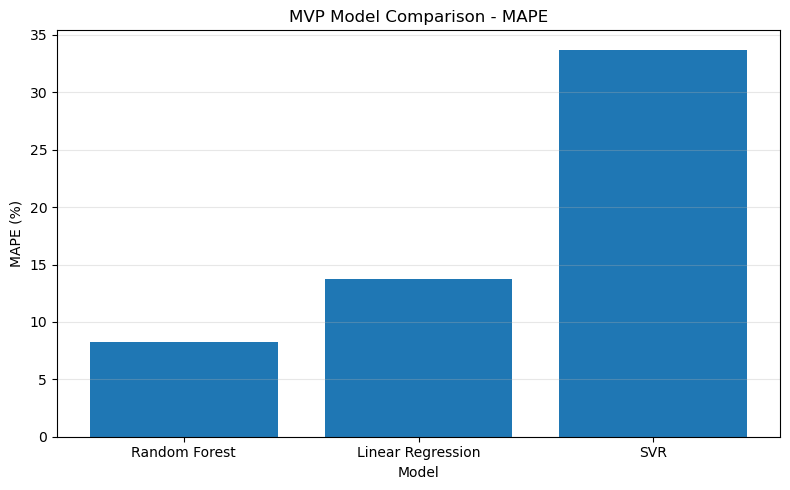

In [93]:
plot_df = mvp_results.sort_values("MAPE (%)")

plt.figure(figsize=(8, 5))
plt.bar(plot_df["Model"], plot_df["MAPE (%)"])

plt.title("MVP Model Comparison - MAPE")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

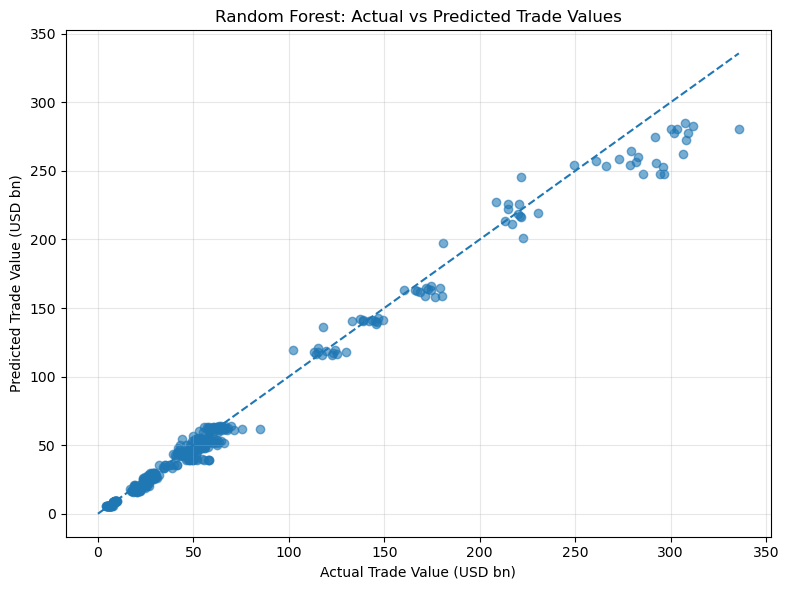

In [94]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_actual / 1_000_000_000,
    rf_pred / 1_000_000_000,
    alpha=0.6
)

max_value = max(
    y_test_actual.max() / 1_000_000_000,
    rf_pred.max() / 1_000_000_000
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.title("Random Forest: Actual vs Predicted Trade Values")
plt.xlabel("Actual Trade Value (USD bn)")
plt.ylabel("Predicted Trade Value (USD bn)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

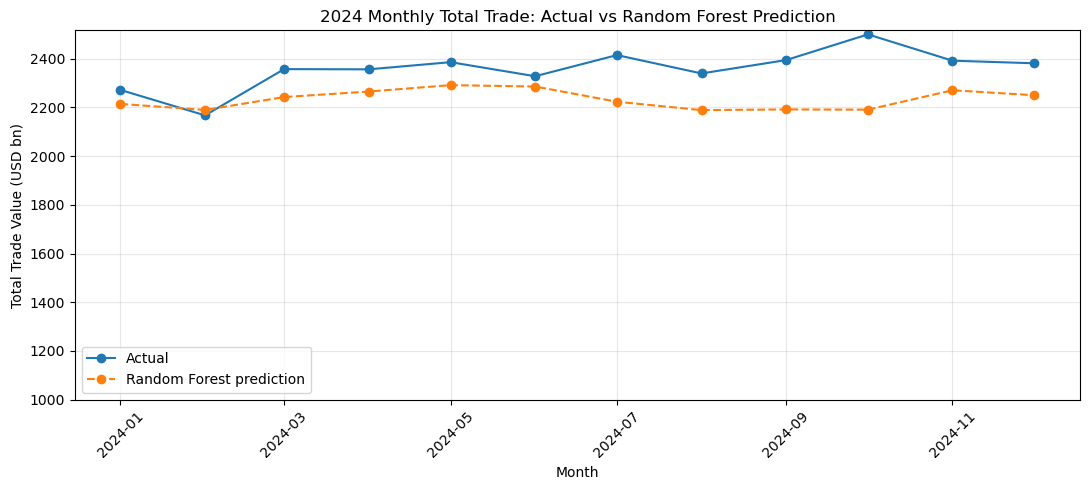

In [98]:
rf_plot_df = test_df[["date"]].copy()

rf_plot_df["Actual Trade Value"] = y_test_actual.values / 1_000_000_000
rf_plot_df["Predicted Trade Value"] = rf_pred / 1_000_000_000

monthly_results = rf_plot_df.groupby("date")[[
    "Actual Trade Value",
    "Predicted Trade Value"
]].sum()

plt.figure(figsize=(11, 5))

plt.plot(
    monthly_results.index,
    monthly_results["Actual Trade Value"],
    marker="o",
    label="Actual"
)

plt.plot(
    monthly_results.index,
    monthly_results["Predicted Trade Value"],
    marker="o",
    linestyle="--",
    label="Random Forest prediction"
)

plt.title("2024 Monthly Total Trade: Actual vs Random Forest Prediction")
plt.xlabel("Month")
plt.ylabel("Total Trade Value (USD bn)")
plt.legend()
plt.grid(alpha=0.3)

plt.ylim(bottom=1000)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

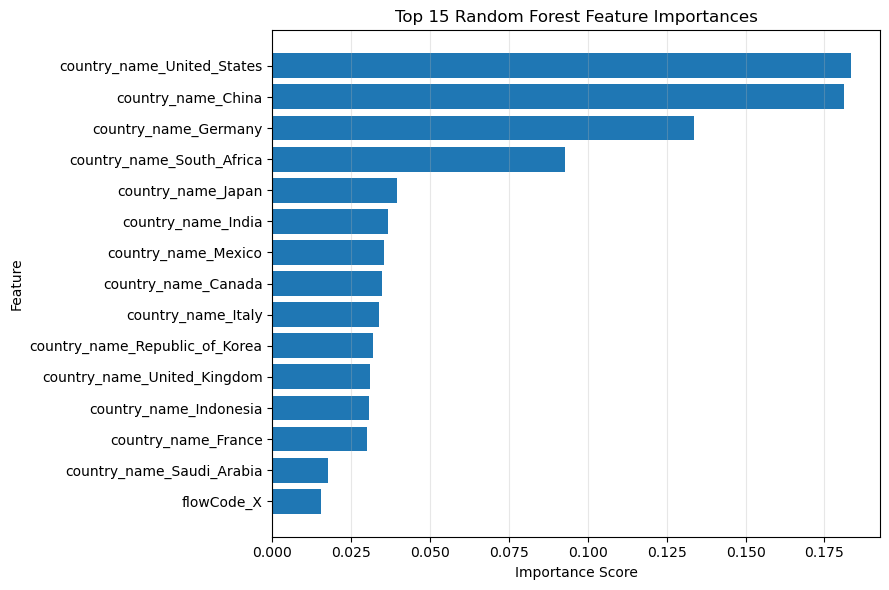

In [99]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

top_features = feature_importance.sort_values(
    "Importance",
    ascending=False
).head(15)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

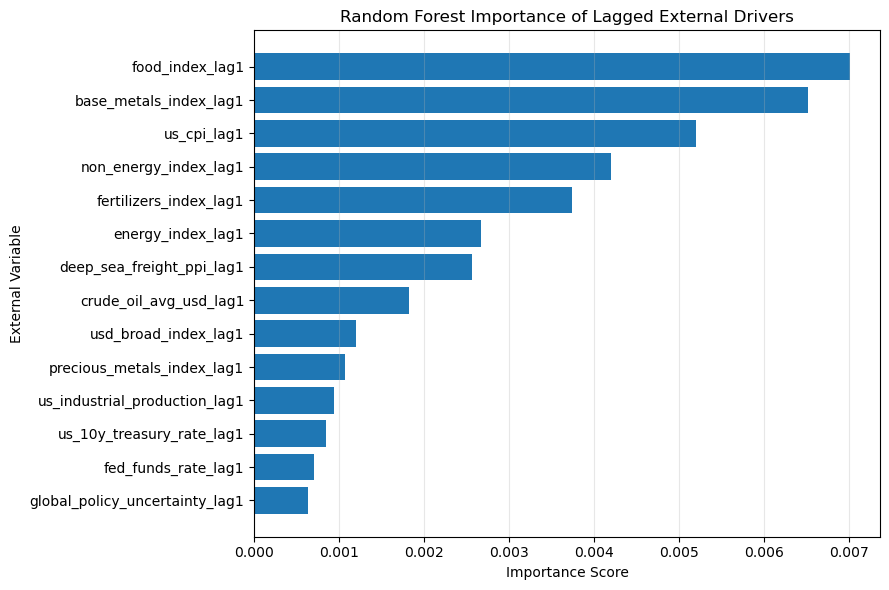

In [100]:
external_importance = feature_importance[
    feature_importance["Feature"].str.endswith("_lag1")
].sort_values("Importance", ascending=False)

plt.figure(figsize=(9, 6))

plt.barh(
    external_importance["Feature"],
    external_importance["Importance"]
)

plt.title("Random Forest Importance of Lagged External Drivers")
plt.xlabel("Importance Score")
plt.ylabel("External Variable")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

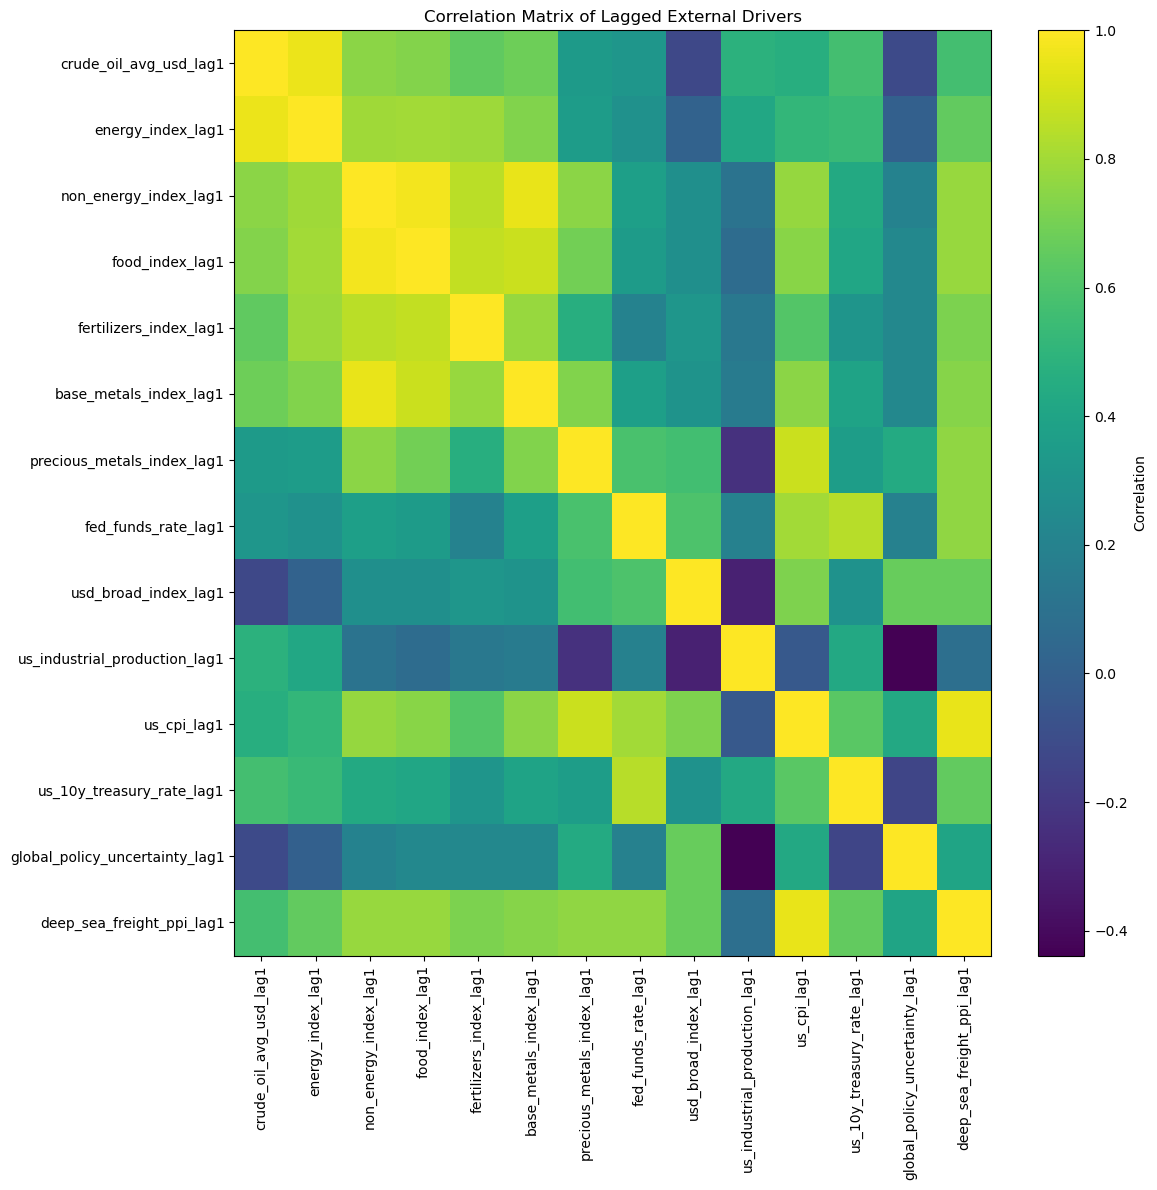

In [103]:
lag_feature_cols = [col + "_lag1" for col in external_cols]

corr_matrix = monthly_external[lag_feature_cols].corr()

plt.figure(figsize=(12, 12))

plt.imshow(corr_matrix, aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(lag_feature_cols)),
    lag_feature_cols,
    rotation=90
)

plt.yticks(
    range(len(lag_feature_cols)),
    lag_feature_cols
)

plt.title("Correlation Matrix of Lagged External Drivers")

plt.tight_layout()
plt.show()

In [104]:
total_2024_trade = y_test_actual.sum()
average_monthly_2024_trade = y_test_actual.groupby(test_df["date"].values).sum().mean()

print(f"Aggregate 2024 test-set trade: USD {total_2024_trade / 1e12:.2f} trillion")
print(f"Average monthly aggregate trade: USD {average_monthly_2024_trade / 1e12:.2f} trillion")

Aggregate 2024 test-set trade: USD 28.29 trillion
Average monthly aggregate trade: USD 2.36 trillion


In [105]:
country_results = pd.DataFrame({
    "Country": model_df.loc[test_df.index, "country_name"].values,
    "Actual": y_test_actual.values,
    "Predicted": rf_pred
})

country_results.head()

,Country,Actual,Predicted
0,Argentina,4.603955e+09,5.482742e+09
1,Argentina,5.412324e+09,5.401876e+09
2,Argentina,4.118057e+09,5.377869e+09
3,Argentina,5.550152e+09,5.365466e+09
4,Argentina,4.331571e+09,5.371091e+09


In [106]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

country_metrics = []

for country in country_results["Country"].unique():
    data = country_results[country_results["Country"] == country]
    
    mae = mean_absolute_error(data["Actual"], data["Predicted"])
    rmse = mean_squared_error(data["Actual"], data["Predicted"]) ** 0.5
    r2 = r2_score(data["Actual"], data["Predicted"])
    mape = (abs((data["Actual"] - data["Predicted"]) / data["Actual"])).mean() * 100
    
    country_metrics.append([country, mae, rmse, r2, mape])

country_metrics_df = pd.DataFrame(
    country_metrics,
    columns=["Country", "MAE", "RMSE", "R2", "MAPE"]
)

country_metrics_df.sort_values("MAPE")

,Country,MAE,RMSE,R2,MAPE
6,Germany,5.903955e+09,7.420039e+09,0.688402,4.729706
1,Australia,1.250613e+09,1.683052e+09,0.344946,4.784260
10,Japan,2.864803e+09,3.445497e+09,0.223137,4.906284
14,South_Africa,4.731656e+08,5.726658e+08,0.311593,5.369288
5,France,3.119840e+09,3.850594e+09,0.600970,5.553551
12,Republic_of_Korea,3.424435e+09,3.817922e+09,-0.584312,6.152983
4,China,1.867282e+10,2.296282e+10,0.751209,6.842120
17,United_States,1.833032e+10,2.319955e+10,0.821826,7.503444
16,United_Kingdom,4.841374e+09,7.031286e+09,0.721865,7.993268
15,Turkiye,2.057798e+09,2.302394e+09,0.646159,8.227904


In [107]:
country_metrics_display = country_metrics_df.copy()

country_metrics_display["MAE_USD_bn"] = country_metrics_display["MAE"] / 1_000_000_000
country_metrics_display["RMSE_USD_bn"] = country_metrics_display["RMSE"] / 1_000_000_000

country_metrics_display = country_metrics_display[
    ["Country", "MAE_USD_bn", "RMSE_USD_bn", "R2", "MAPE"]
]

country_metrics_display = country_metrics_display.sort_values("MAPE")

country_metrics_display.round(2)

,Country,MAE_USD_bn,RMSE_USD_bn,R2,MAPE
6,Germany,5.90,7.42,0.69,4.73
1,Australia,1.25,1.68,0.34,4.78
10,Japan,2.86,3.45,0.22,4.91
14,South_Africa,0.47,0.57,0.31,5.37
5,France,3.12,3.85,0.60,5.55
12,Republic_of_Korea,3.42,3.82,-0.58,6.15
4,China,18.67,22.96,0.75,6.84
17,United_States,18.33,23.20,0.82,7.50
16,United_Kingdom,4.84,7.03,0.72,7.99
15,Turkiye,2.06,2.30,0.65,8.23


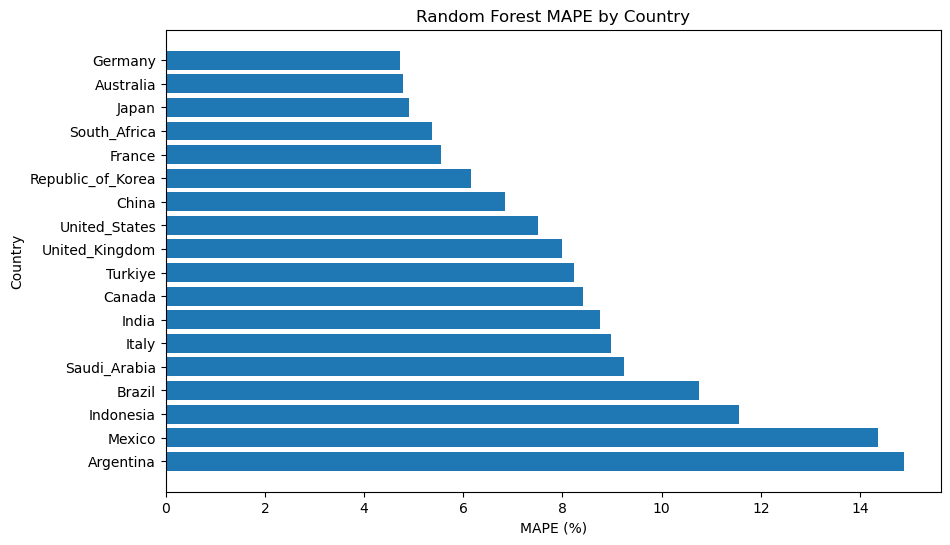

In [108]:
import matplotlib.pyplot as plt

plot_data = country_metrics_display.sort_values("MAPE", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(plot_data["Country"], plot_data["MAPE"])
plt.xlabel("MAPE (%)")
plt.ylabel("Country")
plt.title("Random Forest MAPE by Country")
plt.show()

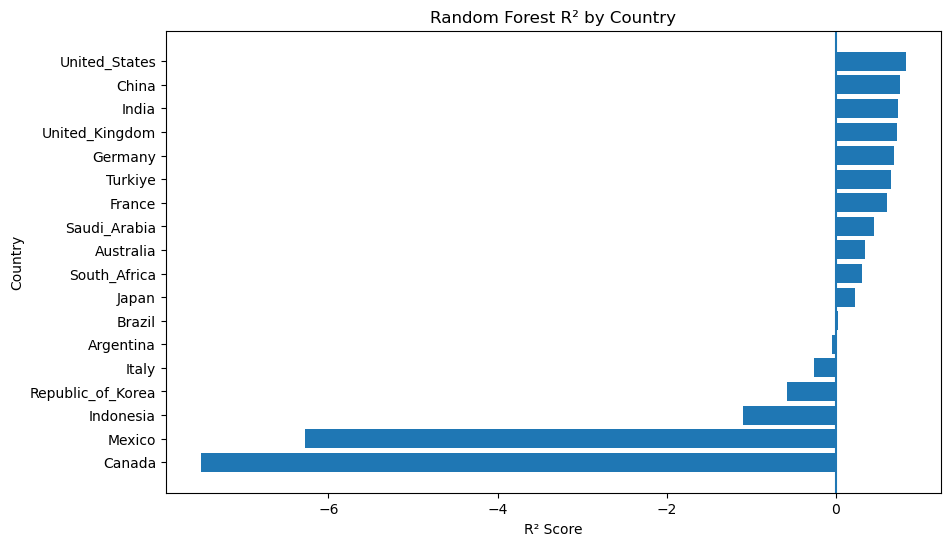

In [109]:
plot_data = country_metrics_display.sort_values("R2")

plt.figure(figsize=(10, 6))
plt.barh(plot_data["Country"], plot_data["R2"])
plt.axvline(0)
plt.xlabel("R² Score")
plt.ylabel("Country")
plt.title("Random Forest R² by Country")
plt.show()

In [110]:
canada_results = country_results[country_results["Country"] == "Canada"]

canada_results

,Country,Actual,Predicted
72,Canada,4.186179e+10,4.506149e+10
73,Canada,4.533378e+10,4.536258e+10
74,Canada,4.427826e+10,4.483295e+10
75,Canada,4.549343e+10,4.526057e+10
76,Canada,4.775550e+10,4.502239e+10
77,Canada,4.738599e+10,4.558485e+10
78,Canada,4.784127e+10,4.506841e+10
79,Canada,4.712502e+10,4.581764e+10
80,Canada,4.830561e+10,4.510306e+10
81,Canada,4.777392e+10,4.600549e+10


In [111]:
country_results["Date"] = model_df.loc[test_df.index, "date"].values
country_results["Flow"] = model_df.loc[test_df.index, "flowDesc"].values

canada_results = country_results[country_results["Country"] == "Canada"]

canada_results[["Date", "Flow", "Actual", "Predicted"]]

,Date,Flow,Actual,Predicted
72,2024-01-01,Import,4.186179e+10,4.506149e+10
73,2024-01-01,Export,4.533378e+10,4.536258e+10
74,2024-02-01,Import,4.427826e+10,4.483295e+10
75,2024-02-01,Export,4.549343e+10,4.526057e+10
76,2024-03-01,Import,4.775550e+10,4.502239e+10
77,2024-03-01,Export,4.738599e+10,4.558485e+10
78,2024-04-01,Import,4.784127e+10,4.506841e+10
79,2024-04-01,Export,4.712502e+10,4.581764e+10
80,2024-05-01,Import,4.830561e+10,4.510306e+10
81,2024-05-01,Export,4.777392e+10,4.600549e+10


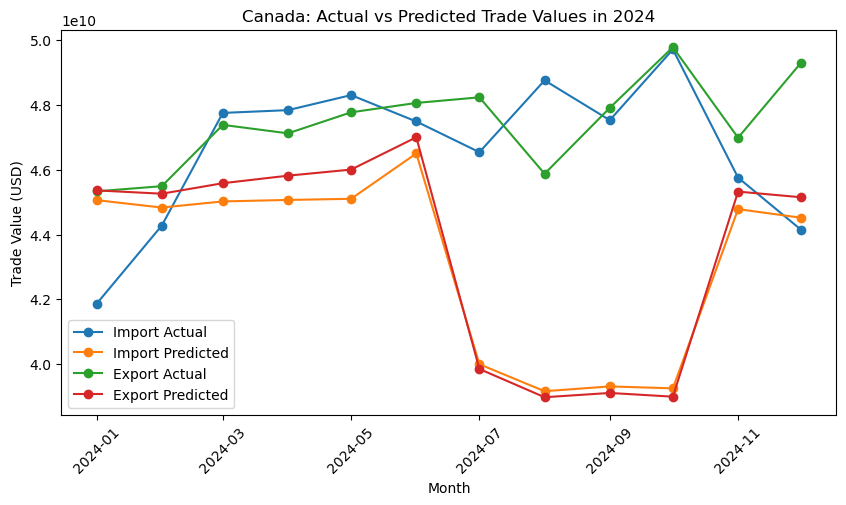

In [112]:
canada_imports = canada_results[canada_results["Flow"] == "Import"]
canada_exports = canada_results[canada_results["Flow"] == "Export"]

plt.figure(figsize=(10, 5))

plt.plot(canada_imports["Date"], canada_imports["Actual"], marker="o", label="Import Actual")
plt.plot(canada_imports["Date"], canada_imports["Predicted"], marker="o", label="Import Predicted")

plt.plot(canada_exports["Date"], canada_exports["Actual"], marker="o", label="Export Actual")
plt.plot(canada_exports["Date"], canada_exports["Predicted"], marker="o", label="Export Predicted")

plt.title("Canada: Actual vs Predicted Trade Values in 2024")
plt.xlabel("Month")
plt.ylabel("Trade Value (USD)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [113]:
canada_features = model_df[
    (model_df["country_name"] == "Canada") &
    (model_df["date"].dt.year == 2024)
]

canada_features[
    ["date", "crude_oil_avg_usd_lag1", "energy_index_lag1",
     "non_energy_index_lag1", "usd_broad_index_lag1",
     "us_industrial_production_lag1"]
].drop_duplicates()

,date,crude_oil_avg_usd_lag1,energy_index_lag1,non_energy_index_lag1,usd_broad_index_lag1,us_industrial_production_lag1
1032,2024-01-01,75.7193,99.6082,107.7589,119.833140,100.6031
1034,2024-02-01,77.6723,101.1793,107.1870,120.227357,99.2223
1036,2024-03-01,80.5480,102.2207,107.4910,121.065940,100.2850
1038,2024-04-01,83.5457,104.2348,109.9114,120.658833,100.4575
1040,2024-05-01,88.0113,109.5944,115.5760,122.142814,100.2434
1042,2024-06-01,81.4450,102.6190,115.5886,121.858341,100.8630
1044,2024-07-01,81.2050,103.7664,114.1568,123.709479,100.8940
1046,2024-08-01,83.2587,105.9796,111.7083,123.382436,99.9757
1048,2024-09-01,78.1210,102.6462,109.6065,122.613741,100.4309
1050,2024-10-01,72.4243,95.3732,112.1884,121.884855,99.8084


In [114]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance.sort_values("Importance", ascending=False).head(15)

,Feature,Importance
33,country_name_United_States,0.183427
20,country_name_China,0.181103
22,country_name_Germany,0.133624
30,country_name_South_Africa,0.092638
26,country_name_Japan,0.039658
23,country_name_India,0.036825
27,country_name_Mexico,0.035554
19,country_name_Canada,0.034836
25,country_name_Italy,0.033837
28,country_name_Republic_of_Korea,0.031928


In [115]:
non_country_features = feature_importance[
    ~feature_importance["Feature"].str.contains("country_name")
]

non_country_features.sort_values("Importance", ascending=False).head(15)

,Feature,Importance
34,flowCode_X,0.015541
6,food_index_lag1,0.007018
8,base_metals_index_lag1,0.006526
13,us_cpi_lag1,0.005197
5,non_energy_index_lag1,0.004201
7,fertilizers_index_lag1,0.003742
4,energy_index_lag1,0.002668
16,deep_sea_freight_ppi_lag1,0.002570
3,crude_oil_avg_usd_lag1,0.001821
11,usd_broad_index_lag1,0.001200


In [116]:
[col for col in X_train.columns if "lag" in col.lower()]

['crude_oil_avg_usd_lag1',
 'energy_index_lag1',
 'non_energy_index_lag1',
 'food_index_lag1',
 'fertilizers_index_lag1',
 'base_metals_index_lag1',
 'precious_metals_index_lag1',
 'fed_funds_rate_lag1',
 'usd_broad_index_lag1',
 'us_industrial_production_lag1',
 'us_cpi_lag1',
 'us_10y_treasury_rate_lag1',
 'global_policy_uncertainty_lag1',
 'deep_sea_freight_ppi_lag1']

In [117]:
# Saving current Random Forest result (external only)

rf_baseline_predictions = country_results.copy()
rf_baseline_country_metrics = country_metrics_display.copy()

print("Baseline Random Forest results saved.")

Baseline Random Forest results saved.


In [118]:
model_df = model_df.sort_values(
    ["country_name", "flowCode", "date"]
).copy()

model_df["trade_value_lag12"] = model_df.groupby(
    ["country_name", "flowCode"]
)["primaryValue"].shift(12)

model_df[
    ["country_name", "flowDesc", "date", "primaryValue", "trade_value_lag12"]
].head(15)

,country_name,flowDesc,date,primaryValue,trade_value_lag12
2,Argentina,Import,2014-02-01,5.539307e+09,NaN
4,Argentina,Import,2014-03-01,5.524368e+09,NaN
6,Argentina,Import,2014-04-01,5.414486e+09,NaN
8,Argentina,Import,2014-05-01,5.760059e+09,NaN
10,Argentina,Import,2014-06-01,5.979561e+09,NaN
12,Argentina,Import,2014-07-01,5.898326e+09,NaN
14,Argentina,Import,2014-08-01,5.638072e+09,NaN
16,Argentina,Import,2014-09-01,5.495982e+09,NaN
18,Argentina,Import,2014-10-01,5.514950e+09,NaN
20,Argentina,Import,2014-11-01,4.762304e+09,NaN


In [119]:
seasonal_model_df = model_df.dropna(subset=["trade_value_lag12"]).copy()

print("Rows before:", len(model_df))
print("Rows after:", len(seasonal_model_df))
print("Missing lag values:", seasonal_model_df["trade_value_lag12"].isna().sum())

Rows before: 4636
Rows after: 4204
Missing lag values: 0


In [120]:
seasonal_model_df_encoded = pd.get_dummies(
    seasonal_model_df,
    columns=["country_name", "flowCode"],
    drop_first=True
)

print("Seasonal model shape:", seasonal_model_df_encoded.shape)

Seasonal model shape: (4204, 41)


In [121]:
seasonal_train_df = seasonal_model_df_encoded[
    seasonal_model_df_encoded["year"] <= 2023
]

seasonal_test_df = seasonal_model_df_encoded[
    seasonal_model_df_encoded["year"] == 2024
]

print("Seasonal train shape:", seasonal_train_df.shape)
print("Seasonal test shape:", seasonal_test_df.shape)

Seasonal train shape: (3772, 41)
Seasonal test shape: (432, 41)


In [122]:
seasonal_drop_cols = [
    "primaryValue",
    "log_primaryValue",
    "date",
    "period",
    "flowDesc"
]

X_train_seasonal = seasonal_train_df.drop(columns=seasonal_drop_cols)
y_train_seasonal = seasonal_train_df["log_primaryValue"]

X_test_seasonal = seasonal_test_df.drop(columns=seasonal_drop_cols)
y_test_seasonal = seasonal_test_df["log_primaryValue"]

print("X_train seasonal shape:", X_train_seasonal.shape)
print("X_test seasonal shape:", X_test_seasonal.shape)

X_train seasonal shape: (3772, 36)
X_test seasonal shape: (432, 36)


In [123]:
"trade_value_lag12" in X_train_seasonal.columns

True

In [124]:
from sklearn.ensemble import RandomForestRegressor

rf_seasonal = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_seasonal.fit(X_train_seasonal, y_train_seasonal)

seasonal_pred_log = rf_seasonal.predict(X_test_seasonal)

print("Seasonal Random Forest trained.")

Seasonal Random Forest trained.


In [125]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Converting predictions and actual values back from log scale
seasonal_pred = np.expm1(seasonal_pred_log)
seasonal_actual = np.expm1(y_test_seasonal)

# Calculating evaluation metrics
seasonal_mae = mean_absolute_error(seasonal_actual, seasonal_pred)

seasonal_rmse = np.sqrt(
    mean_squared_error(seasonal_actual, seasonal_pred)
)

seasonal_r2 = r2_score(seasonal_actual, seasonal_pred)

seasonal_mape = (
    abs((seasonal_actual - seasonal_pred) / seasonal_actual).mean() * 100
)

In [126]:
# Display results
print("Seasonal Random Forest results")
print("MAE:", seasonal_mae)
print("RMSE:", seasonal_rmse)
print("R2:", seasonal_r2)
print("MAPE:", seasonal_mape)

Seasonal Random Forest results
MAE: 3881051913.6342216
RMSE: 6868072604.185765
R2: 0.9904315667611717
MAPE: 6.568867460265873


In [127]:
seasonal_country_results = pd.DataFrame({
    "Country": seasonal_model_df.loc[seasonal_test_df.index, "country_name"].values,
    "Actual": seasonal_actual.values,
    "Predicted": seasonal_pred
})

seasonal_country_results.head()

,Country,Actual,Predicted
0,Argentina,4.603955e+09,5.239486e+09
1,Argentina,4.118057e+09,4.948272e+09
2,Argentina,4.331571e+09,5.995441e+09
3,Argentina,4.704521e+09,5.718709e+09
4,Argentina,5.012117e+09,6.416580e+09


In [128]:
seasonal_country_metrics = []

In [129]:
for country in seasonal_country_results["Country"].unique():
    data = seasonal_country_results[
        seasonal_country_results["Country"] == country
    ]
    
    print(country, len(data))

Argentina 24
Australia 24
Brazil 24
Canada 24
China 24
France 24
Germany 24
India 24
Indonesia 24
Italy 24
Japan 24
Mexico 24
Republic_of_Korea 24
Saudi_Arabia 24
South_Africa 24
Turkiye 24
United_Kingdom 24
United_States 24


In [130]:
argentina_data = seasonal_country_results[
    seasonal_country_results["Country"] == "Argentina"
]

argentina_mae = mean_absolute_error(
    argentina_data["Actual"],
    argentina_data["Predicted"]
)

argentina_rmse = np.sqrt(
    mean_squared_error(
        argentina_data["Actual"],
        argentina_data["Predicted"]
    )
)

argentina_r2 = r2_score(
    argentina_data["Actual"],
    argentina_data["Predicted"]
)

argentina_mape = (
    abs(
        (argentina_data["Actual"] - argentina_data["Predicted"])
        / argentina_data["Actual"]
    ).mean()
    * 100
)

In [131]:
print("Argentina MAE:", argentina_mae)
print("Argentina RMSE:", argentina_rmse)
print("Argentina R2:", argentina_r2)
print("Argentina MAPE:", argentina_mape)

Argentina MAE: 864795205.0899845
Argentina RMSE: 1001359984.5164468
Argentina R2: -0.006175981549181309
Argentina MAPE: 15.509579217055688


In [132]:
for country in seasonal_country_results["Country"].unique():
    data = seasonal_country_results[
        seasonal_country_results["Country"] == country
    ]
    
    mae = mean_absolute_error(data["Actual"], data["Predicted"])
    
    seasonal_country_metrics.append([country, mae])

seasonal_country_metrics[:5]

[['Argentina', 864795205.0899845],
 ['Australia', 1311601299.863109],
 ['Brazil', 2557683175.314189],
 ['Canada', 1835625234.5023584],
 ['China', 12868092739.263527]]

In [133]:
seasonal_country_metrics = []

In [134]:
for country in seasonal_country_results["Country"].unique():
    data = seasonal_country_results[
        seasonal_country_results["Country"] == country
    ]
    
    mae = mean_absolute_error(data["Actual"], data["Predicted"])
    
    rmse = np.sqrt(
        mean_squared_error(data["Actual"], data["Predicted"])
    )
    
    seasonal_country_metrics.append([country, mae, rmse])

seasonal_country_metrics[:5]

[['Argentina', 864795205.0899845, np.float64(1001359984.5164468)],
 ['Australia', 1311601299.863109, np.float64(1538033049.1086524)],
 ['Brazil', 2557683175.314189, np.float64(3183982335.183747)],
 ['Canada', 1835625234.5023584, np.float64(2235283075.3097296)],
 ['China', 12868092739.263527, np.float64(16524529263.628458)]]

In [135]:
seasonal_country_metrics = []

In [136]:
for country in seasonal_country_results["Country"].unique():
    data = seasonal_country_results[
        seasonal_country_results["Country"] == country
    ]
    
    mae = mean_absolute_error(data["Actual"], data["Predicted"])
    
    rmse = np.sqrt(
        mean_squared_error(data["Actual"], data["Predicted"])
    )
    
    r2 = r2_score(data["Actual"], data["Predicted"])
    
    seasonal_country_metrics.append([country, mae, rmse, r2])

seasonal_country_metrics[:5]

[['Argentina',
  864795205.0899845,
  np.float64(1001359984.5164468),
  -0.006175981549181309],
 ['Australia',
  1311601299.863109,
  np.float64(1538033049.1086524),
  0.4529668049843383],
 ['Brazil',
  2557683175.314189,
  np.float64(3183982335.183747),
  0.035512777944394],
 ['Canada',
  1835625234.5023584,
  np.float64(2235283075.3097296),
  -0.475047519610603],
 ['China',
  12868092739.263527,
  np.float64(16524529263.628458),
  0.8711623341006146]]

In [137]:
seasonal_country_metrics = []

In [138]:
for country in seasonal_country_results["Country"].unique():
    data = seasonal_country_results[
        seasonal_country_results["Country"] == country
    ]
    
    mae = mean_absolute_error(data["Actual"], data["Predicted"])
    
    rmse = np.sqrt(
        mean_squared_error(data["Actual"], data["Predicted"])
    )
    
    r2 = r2_score(data["Actual"], data["Predicted"])
    
    mape = (
        abs(
            (data["Actual"] - data["Predicted"])
            / data["Actual"]
        ).mean()
        * 100
    )
    
    seasonal_country_metrics.append(
        [country, mae, rmse, r2, mape]
    )

seasonal_country_metrics[:5]

[['Argentina',
  864795205.0899845,
  np.float64(1001359984.5164468),
  -0.006175981549181309,
  np.float64(15.509579217055688)],
 ['Australia',
  1311601299.863109,
  np.float64(1538033049.1086524),
  0.4529668049843383,
  np.float64(5.014861882103183)],
 ['Brazil',
  2557683175.314189,
  np.float64(3183982335.183747),
  0.035512777944394,
  np.float64(9.9309388138539)],
 ['Canada',
  1835625234.5023584,
  np.float64(2235283075.3097296),
  -0.475047519610603,
  np.float64(3.8717694526509256)],
 ['China',
  12868092739.263527,
  np.float64(16524529263.628458),
  0.8711623341006146,
  np.float64(4.839730250039498)]]

In [139]:
seasonal_country_metrics_df = pd.DataFrame(
    seasonal_country_metrics,
    columns=["Country", "MAE", "RMSE", "R2", "MAPE"]
)

seasonal_country_metrics_df["MAE_USD_bn"] = (
    seasonal_country_metrics_df["MAE"] / 1_000_000_000
)

seasonal_country_metrics_df["RMSE_USD_bn"] = (
    seasonal_country_metrics_df["RMSE"] / 1_000_000_000
)

seasonal_country_metrics_display = seasonal_country_metrics_df[
    ["Country", "MAE_USD_bn", "RMSE_USD_bn", "R2", "MAPE"]
]

seasonal_country_metrics_display.sort_values("MAPE").round(2)

,Country,MAE_USD_bn,RMSE_USD_bn,R2,MAPE
3,Canada,1.84,2.24,-0.48,3.87
5,France,2.35,2.80,0.79,4.05
10,Japan,2.57,2.97,0.42,4.23
9,Italy,2.53,3.23,0.60,4.65
4,China,12.87,16.52,0.87,4.84
17,United_States,12.68,17.20,0.90,5.00
1,Australia,1.31,1.54,0.45,5.01
15,Turkiye,1.33,1.72,0.80,5.20
8,Indonesia,1.25,1.54,0.45,5.86
14,South_Africa,0.53,0.62,0.20,5.94


In [140]:
comparison_mape = rf_baseline_country_metrics[
    ["Country", "MAPE", "R2"]
].merge(
    seasonal_country_metrics_display[
        ["Country", "MAPE", "R2"]
    ],
    on="Country",
    suffixes=("_Baseline", "_Seasonal")
)

comparison_mape["MAPE_Change"] = (
    comparison_mape["MAPE_Seasonal"]
    - comparison_mape["MAPE_Baseline"]
)

comparison_mape["R2_Change"] = (
    comparison_mape["R2_Seasonal"]
    - comparison_mape["R2_Baseline"]
)

comparison_mape.sort_values("MAPE_Change").round(2)

,Country,MAPE_Baseline,R2_Baseline,MAPE_Seasonal,R2_Seasonal,MAPE_Change,R2_Change
16,Mexico,14.35,-6.27,6.54,-0.46,-7.82,5.81
15,Indonesia,11.56,-1.10,5.86,0.45,-5.70,1.55
10,Canada,8.41,-7.51,3.87,-0.48,-4.53,7.03
12,Italy,8.98,-0.26,4.65,0.60,-4.32,0.86
13,Saudi_Arabia,9.24,0.45,6.00,0.73,-3.24,0.28
9,Turkiye,8.23,0.65,5.20,0.80,-3.03,0.16
7,United_States,7.50,0.82,5.00,0.90,-2.50,0.08
6,China,6.84,0.75,4.84,0.87,-2.00,0.12
4,France,5.55,0.60,4.05,0.79,-1.50,0.19
11,India,8.75,0.74,7.52,0.83,-1.23,0.10


In [141]:
model_df["lag12_date"] = model_df.groupby(
    ["country_name", "flowCode"]
)["date"].shift(12)

wrong_lag_rows = model_df[
    model_df["trade_value_lag12"].notna()
    & (
        model_df["lag12_date"]
        != model_df["date"] - pd.DateOffset(years=1)
    )
]

print("Rows where lag12 is not exactly one year earlier:", len(wrong_lag_rows))

Rows where lag12 is not exactly one year earlier: 66


In [142]:
model_df = model_df.drop(
    columns=["trade_value_lag12", "lag12_date"],
    errors="ignore"
)

In [143]:
lag_lookup = model_df[
    ["country_name", "flowCode", "date", "primaryValue"]
].copy()

lag_lookup["date"] = lag_lookup["date"] + pd.DateOffset(years=1)

lag_lookup = lag_lookup.rename(
    columns={"primaryValue": "trade_value_lag12"}
)

lag_lookup.head()

,country_name,flowCode,date,trade_value_lag12
2,Argentina,M,2015-02-01,5.539307e+09
4,Argentina,M,2015-03-01,5.524368e+09
6,Argentina,M,2015-04-01,5.414486e+09
8,Argentina,M,2015-05-01,5.760059e+09
10,Argentina,M,2015-06-01,5.979561e+09


In [144]:
model_df = model_df.merge(
    lag_lookup,
    on=["country_name", "flowCode", "date"],
    how="left"
)

model_df[
    ["country_name", "flowDesc", "date", "primaryValue", "trade_value_lag12"]
].head(15)

,country_name,flowDesc,date,primaryValue,trade_value_lag12
0,Argentina,Import,2014-02-01,5.539307e+09,NaN
1,Argentina,Import,2014-03-01,5.524368e+09,NaN
2,Argentina,Import,2014-04-01,5.414486e+09,NaN
3,Argentina,Import,2014-05-01,5.760059e+09,NaN
4,Argentina,Import,2014-06-01,5.979561e+09,NaN
5,Argentina,Import,2014-07-01,5.898326e+09,NaN
6,Argentina,Import,2014-08-01,5.638072e+09,NaN
7,Argentina,Import,2014-09-01,5.495982e+09,NaN
8,Argentina,Import,2014-10-01,5.514950e+09,NaN
9,Argentina,Import,2014-11-01,4.762304e+09,NaN


In [145]:
print("Rows with a true 12-month lag:", model_df["trade_value_lag12"].notna().sum())
print("Rows without a true 12-month lag:", model_df["trade_value_lag12"].isna().sum())

Rows with a true 12-month lag: 4196
Rows without a true 12-month lag: 440


In [146]:
seasonal_model_df = model_df.dropna(
    subset=["trade_value_lag12"]
).copy()

print("Rows kept for seasonal model:", len(seasonal_model_df))


Rows kept for seasonal model: 4196


In [147]:
seasonal_model_df_encoded = pd.get_dummies(
    seasonal_model_df,
    columns=["country_name", "flowCode"],
    drop_first=True
)

print("Seasonal model shape:", seasonal_model_df_encoded.shape)

Seasonal model shape: (4196, 41)


In [148]:
seasonal_train_df = seasonal_model_df_encoded[
    seasonal_model_df_encoded["year"] <= 2023
]

seasonal_test_df = seasonal_model_df_encoded[
    seasonal_model_df_encoded["year"] == 2024
]

print("Seasonal train shape:", seasonal_train_df.shape)
print("Seasonal test shape:", seasonal_test_df.shape)

Seasonal train shape: (3764, 41)
Seasonal test shape: (432, 41)


In [149]:
seasonal_drop_cols = [
    "primaryValue",
    "log_primaryValue",
    "date",
    "period",
    "flowDesc"
]

X_train_seasonal = seasonal_train_df.drop(
    columns=seasonal_drop_cols
)

X_test_seasonal = seasonal_test_df.drop(
    columns=seasonal_drop_cols
)

y_train_seasonal = seasonal_train_df["log_primaryValue"]
y_test_seasonal = seasonal_test_df["log_primaryValue"]

print("X_train shape:", X_train_seasonal.shape)
print("X_test shape:", X_test_seasonal.shape)

X_train shape: (3764, 36)
X_test shape: (432, 36)


In [150]:
"trade_value_lag12" in X_train_seasonal.columns

True

In [151]:
rf_seasonal = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_seasonal.fit(X_train_seasonal, y_train_seasonal)

seasonal_pred_log = rf_seasonal.predict(X_test_seasonal)

print("Corrected seasonal Random Forest trained.")

Corrected seasonal Random Forest trained.


In [152]:
seasonal_pred = np.expm1(seasonal_pred_log)

seasonal_actual = np.expm1(y_test_seasonal)

In [153]:
seasonal_mae = mean_absolute_error(
    seasonal_actual,
    seasonal_pred
)

print("Corrected seasonal MAE:", seasonal_mae)

Corrected seasonal MAE: 3937994096.020691


In [154]:
seasonal_rmse = np.sqrt(
    mean_squared_error(
        seasonal_actual,
        seasonal_pred
    )
)

print("Corrected seasonal RMSE:", seasonal_rmse)

Corrected seasonal RMSE: 6945299567.2508335


In [155]:
seasonal_r2 = r2_score(
    seasonal_actual,
    seasonal_pred
)

print("Corrected seasonal R2:", seasonal_r2)

Corrected seasonal R2: 0.9902151754862532


In [156]:
seasonal_mape = (
    abs(
        (seasonal_actual - seasonal_pred)
        / seasonal_actual
    ).mean()
    * 100
)

print("Corrected seasonal MAPE:", seasonal_mape)

Corrected seasonal MAPE: 6.658806192593324


In [157]:
overall_model_comparison = pd.DataFrame({
    "Model": [
        "External-only Random Forest",
        "Random Forest with true 12-month seasonal lag"
    ],
    "MAE_USD_bn": [
        5.020901563862077,
        seasonal_mae / 1_000_000_000
    ],
    "RMSE_USD_bn": [
        8.941761374174374,
        seasonal_rmse / 1_000_000_000
    ],
    "R2": [
        0.9837812556741437,
        seasonal_r2
    ],
    "MAPE": [
        8.277434387115946,
        seasonal_mape
    ]
})

overall_model_comparison.round(2)

,Model,MAE_USD_bn,RMSE_USD_bn,R2,MAPE
0,External-only Random Forest,5.02,8.94,0.98,8.28
1,Random Forest with true 12-month seasonal lag,3.94,6.95,0.99,6.66


In [158]:
seasonal_country_results = pd.DataFrame({
    "Country": seasonal_model_df.loc[
        seasonal_test_df.index, "country_name"
    ].values,
    "Actual": np.asarray(seasonal_actual),
    "Predicted": seasonal_pred
})

seasonal_country_results.head()

,Country,Actual,Predicted
0,Argentina,4.603955e+09,5.201057e+09
1,Argentina,4.118057e+09,4.970995e+09
2,Argentina,4.331571e+09,5.997760e+09
3,Argentina,4.704521e+09,5.770657e+09
4,Argentina,5.012117e+09,6.521666e+09


In [159]:
corrected_seasonal_country_metrics = []

In [160]:
for country in seasonal_country_results["Country"].unique():
    data = seasonal_country_results[
        seasonal_country_results["Country"] == country
    ]
    
    mae = mean_absolute_error(data["Actual"], data["Predicted"])
    
    rmse = np.sqrt(
        mean_squared_error(data["Actual"], data["Predicted"])
    )
    
    r2 = r2_score(data["Actual"], data["Predicted"])
    
    mape = (
        abs(
            (data["Actual"] - data["Predicted"])
            / data["Actual"]
        ).mean()
        * 100
    )
    
    corrected_seasonal_country_metrics.append(
        [country, mae, rmse, r2, mape]
    )

corrected_seasonal_country_metrics[:5]

[['Argentina',
  914139842.90627,
  np.float64(1053523765.2697577),
  -0.11373573539252146,
  np.float64(16.412205520315958)],
 ['Australia',
  1304108630.3920712,
  np.float64(1517828061.3682635),
  0.4672450407383837,
  np.float64(4.988779202250657)],
 ['Brazil',
  2486543836.6635447,
  np.float64(3121559529.178829),
  0.07296010981291912,
  np.float64(9.65335316771913)],
 ['Canada',
  1834180624.4695346,
  np.float64(2322663568.4439383),
  -0.5926251437437706,
  np.float64(3.8648279091835303)],
 ['China',
  13308811341.265993,
  np.float64(17035388350.81291),
  0.8630731137780151,
  np.float64(4.977313778867818)]]

In [161]:
corrected_seasonal_country_metrics_df = pd.DataFrame(
    corrected_seasonal_country_metrics,
    columns=["Country", "MAE", "RMSE", "R2", "MAPE"]
)

corrected_seasonal_country_metrics_df["MAE_USD_bn"] = (
    corrected_seasonal_country_metrics_df["MAE"] / 1_000_000_000
)

corrected_seasonal_country_metrics_df["RMSE_USD_bn"] = (
    corrected_seasonal_country_metrics_df["RMSE"] / 1_000_000_000
)

corrected_seasonal_country_metrics_display = (
    corrected_seasonal_country_metrics_df[
        ["Country", "MAE_USD_bn", "RMSE_USD_bn", "R2", "MAPE"]
    ]
)

corrected_seasonal_country_metrics_display.sort_values("MAPE").round(2)

,Country,MAE_USD_bn,RMSE_USD_bn,R2,MAPE
3,Canada,1.83,2.32,-0.59,3.86
5,France,2.50,2.96,0.76,4.30
10,Japan,2.69,3.12,0.36,4.43
9,Italy,2.61,3.30,0.58,4.80
17,United_States,12.45,17.00,0.90,4.89
4,China,13.31,17.04,0.86,4.98
1,Australia,1.30,1.52,0.47,4.99
15,Turkiye,1.33,1.71,0.80,5.19
14,South_Africa,0.49,0.58,0.28,5.55
13,Saudi_Arabia,1.31,1.66,0.75,5.79


In [162]:
corrected_comparison = rf_baseline_country_metrics[
    ["Country", "MAPE", "R2"]
].merge(
    corrected_seasonal_country_metrics_display[
        ["Country", "MAPE", "R2"]
    ],
    on="Country",
    suffixes=("_Baseline", "_Seasonal")
)

corrected_comparison.head()

,Country,MAPE_Baseline,R2_Baseline,MAPE_Seasonal,R2_Seasonal
0,Germany,4.729706,0.688402,6.410201,0.407491
1,Australia,4.784260,0.344946,4.988779,0.467245
2,Japan,4.906284,0.223137,4.426631,0.362621
3,South_Africa,5.369288,0.311593,5.554117,0.284103
4,France,5.553551,0.600970,4.295420,0.764908


In [163]:
corrected_comparison["MAPE_Change"] = (
    corrected_comparison["MAPE_Seasonal"]
    - corrected_comparison["MAPE_Baseline"]
)

corrected_comparison["R2_Change"] = (
    corrected_comparison["R2_Seasonal"]
    - corrected_comparison["R2_Baseline"]
)

In [164]:
corrected_comparison.sort_values("MAPE_Change").round(2)

,Country,MAPE_Baseline,R2_Baseline,MAPE_Seasonal,R2_Seasonal,MAPE_Change,R2_Change
16,Mexico,14.35,-6.27,6.75,-0.58,-7.60,5.69
15,Indonesia,11.56,-1.10,6.01,0.42,-5.55,1.52
10,Canada,8.41,-7.51,3.86,-0.59,-4.54,6.91
12,Italy,8.98,-0.26,4.80,0.58,-4.18,0.85
13,Saudi_Arabia,9.24,0.45,5.79,0.75,-3.45,0.30
9,Turkiye,8.23,0.65,5.19,0.80,-3.03,0.16
7,United_States,7.50,0.82,4.89,0.90,-2.61,0.08
6,China,6.84,0.75,4.98,0.86,-1.86,0.11
4,France,5.55,0.60,4.30,0.76,-1.26,0.16
11,India,8.75,0.74,7.51,0.83,-1.24,0.09


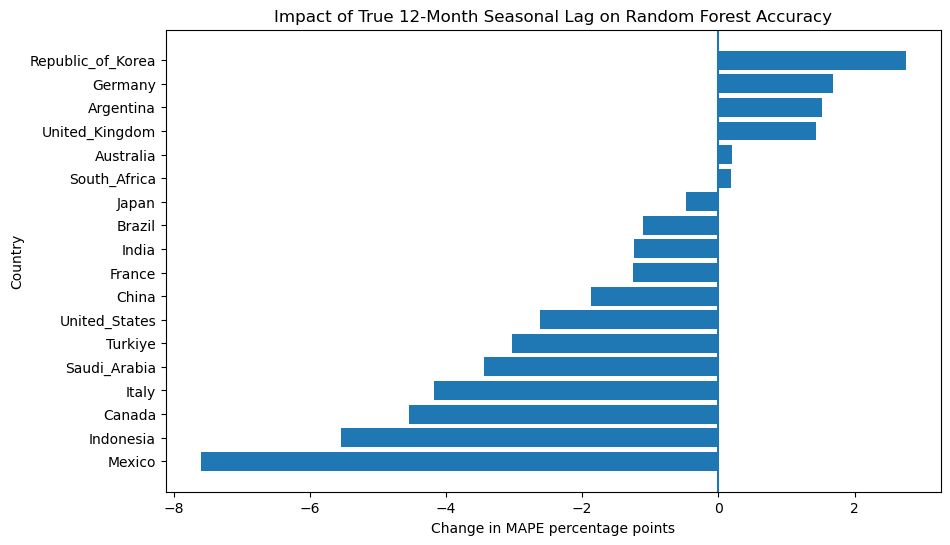

In [165]:
plot_data = corrected_comparison.sort_values("MAPE_Change")

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Country"],
    plot_data["MAPE_Change"]
)

plt.axvline(0)

plt.xlabel("Change in MAPE percentage points")
plt.ylabel("Country")
plt.title("Impact of True 12-Month Seasonal Lag on Random Forest Accuracy")

plt.show()

In [166]:
X_train_matched_external = X_train_seasonal.drop(
    columns=["trade_value_lag12"]
)

X_test_matched_external = X_test_seasonal.drop(
    columns=["trade_value_lag12"]
)

print(X_train_matched_external.shape)
print(X_test_matched_external.shape)

(3764, 35)
(432, 35)


In [167]:
rf_matched_external = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_matched_external.fit(
    X_train_matched_external,
    y_train_seasonal
)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [168]:
matched_external_pred_log = rf_matched_external.predict(
    X_test_matched_external
)

matched_external_pred = np.expm1(
    matched_external_pred_log
)

In [169]:
matched_external_mae = mean_absolute_error(
    seasonal_actual,
    matched_external_pred
)

print("Matched external-only MAE:", matched_external_mae)

Matched external-only MAE: 4948494824.691115


In [170]:
matched_external_rmse = np.sqrt(
    mean_squared_error(
        seasonal_actual,
        matched_external_pred
    )
)

print("Matched external-only RMSE:", matched_external_rmse)

Matched external-only RMSE: 8788401476.374485


In [171]:
matched_external_r2 = r2_score(
    seasonal_actual,
    matched_external_pred
)

print("Matched external-only R2:", matched_external_r2)

Matched external-only R2: 0.984332819292195


In [172]:
matched_external_mape = (
    abs(
        (seasonal_actual - matched_external_pred)
        / seasonal_actual
    ).mean()
    * 100
)

print("Matched external-only MAPE:", matched_external_mape)

Matched external-only MAPE: 8.206654959783135


In [174]:
controlled_model_comparison = pd.DataFrame({
    "Model": [
        "Matched external-only Random Forest",
        "Random Forest with true 12-month seasonal lag"
    ],
    "MAE_USD_bn": [
        matched_external_mae / 1_000_000_000,
        seasonal_mae / 1_000_000_000
    ],
    "RMSE_USD_bn": [
        matched_external_rmse / 1_000_000_000,
        seasonal_rmse / 1_000_000_000
    ],
    "R2": [
        matched_external_r2,
        seasonal_r2
    ],
    "MAPE": [
        matched_external_mape,
        seasonal_mape
    ]
})

controlled_model_comparison.round(3)

,Model,MAE_USD_bn,RMSE_USD_bn,R2,MAPE
0,Matched external-only Random Forest,4.948,8.788,0.984,8.207
1,Random Forest with true 12-month seasonal lag,3.938,6.945,0.990,6.659


In [175]:
matched_external_country_results = pd.DataFrame({
    "Country": seasonal_country_results["Country"].values,
    "Actual": np.asarray(seasonal_actual),
    "Predicted": matched_external_pred
})

matched_external_country_results.head()

,Country,Actual,Predicted
0,Argentina,4.603955e+09,5.418842e+09
1,Argentina,4.118057e+09,5.352867e+09
2,Argentina,4.331571e+09,5.251580e+09
3,Argentina,4.704521e+09,5.497897e+09
4,Argentina,5.012117e+09,5.369233e+09


In [176]:
matched_external_country_metrics = []

In [177]:
for country in matched_external_country_results["Country"].unique():
    data = matched_external_country_results[
        matched_external_country_results["Country"] == country
    ]
    
    mae = mean_absolute_error(data["Actual"], data["Predicted"])
    
    rmse = np.sqrt(
        mean_squared_error(data["Actual"], data["Predicted"])
    )
    
    r2 = r2_score(data["Actual"], data["Predicted"])
    
    mape = (
        abs(
            (data["Actual"] - data["Predicted"])
            / data["Actual"]
        ).mean()
        * 100
    )
    
    matched_external_country_metrics.append(
        [country, mae, rmse, r2, mape]
    )

matched_external_country_metrics[:5]

[['Argentina',
  916908893.3242775,
  np.float64(1074311790.9058444),
  -0.15812161046415762,
  np.float64(15.169308028934445)],
 ['Australia',
  1446410041.0986004,
  np.float64(1884462480.8154135),
  0.1787841252942276,
  np.float64(5.566833786340911)],
 ['Brazil',
  3073799733.4758306,
  np.float64(3583312608.8085513),
  -0.22158748447127286,
  np.float64(11.88348428242893)],
 ['Canada',
  3939788279.0997467,
  np.float64(5263289029.698556),
  -7.178156013141875,
  np.float64(8.236826993649222)],
 ['China',
  19430968043.61798,
  np.float64(23996005292.559723),
  0.7283169442422763,
  np.float64(7.102176052530135)]]

In [178]:
matched_external_country_metrics_df = pd.DataFrame(
    matched_external_country_metrics,
    columns=["Country", "MAE", "RMSE", "R2", "MAPE"]
)

matched_external_country_metrics_df["MAE_USD_bn"] = (
    matched_external_country_metrics_df["MAE"] / 1_000_000_000
)

matched_external_country_metrics_df["RMSE_USD_bn"] = (
    matched_external_country_metrics_df["RMSE"] / 1_000_000_000
)

matched_external_country_metrics_display = (
    matched_external_country_metrics_df[
        ["Country", "MAE_USD_bn", "RMSE_USD_bn", "R2", "MAPE"]
    ]
)

matched_external_country_metrics_display.sort_values("MAPE").round(2)

,Country,MAE_USD_bn,RMSE_USD_bn,R2,MAPE
6,Germany,6.21,7.61,0.67,4.93
10,Japan,2.89,3.55,0.18,4.95
12,Republic_of_Korea,3.00,3.46,-0.30,5.38
5,France,3.12,3.82,0.61,5.50
1,Australia,1.45,1.88,0.18,5.57
14,South_Africa,0.50,0.60,0.25,5.70
4,China,19.43,24.00,0.73,7.10
17,United_States,17.59,21.77,0.84,7.30
16,United_Kingdom,4.61,6.74,0.74,7.70
3,Canada,3.94,5.26,-7.18,8.24


In [179]:
controlled_country_comparison = (
    matched_external_country_metrics_display[
        ["Country", "MAPE", "R2"]
    ]
    .merge(
        corrected_seasonal_country_metrics_display[
            ["Country", "MAPE", "R2"]
        ],
        on="Country",
        suffixes=("_External", "_Seasonal")
    )
)

controlled_country_comparison.head()

,Country,MAPE_External,R2_External,MAPE_Seasonal,R2_Seasonal
0,Argentina,15.169308,-0.158122,16.412206,-0.113736
1,Australia,5.566834,0.178784,4.988779,0.467245
2,Brazil,11.883484,-0.221587,9.653353,0.072960
3,Canada,8.236827,-7.178156,3.864828,-0.592625
4,China,7.102176,0.728317,4.977314,0.863073


In [180]:
controlled_country_comparison["MAPE_Change"] = (
    controlled_country_comparison["MAPE_Seasonal"]
    - controlled_country_comparison["MAPE_External"]
)

controlled_country_comparison["R2_Change"] = (
    controlled_country_comparison["R2_Seasonal"]
    - controlled_country_comparison["R2_External"]
)

In [181]:
controlled_country_comparison.sort_values(
    "MAPE_Change"
).round(2)

,Country,MAPE_External,R2_External,MAPE_Seasonal,R2_Seasonal,MAPE_Change,R2_Change
11,Mexico,12.13,-3.99,6.75,-0.58,-5.38,3.41
13,Saudi_Arabia,10.44,0.32,5.79,0.75,-4.65,0.43
3,Canada,8.24,-7.18,3.86,-0.59,-4.37,6.59
8,Indonesia,10.14,-0.74,6.01,0.42,-4.13,1.16
9,Italy,8.90,-0.25,4.80,0.58,-4.11,0.83
15,Turkiye,8.35,0.61,5.19,0.80,-3.15,0.20
17,United_States,7.30,0.84,4.89,0.90,-2.41,0.06
2,Brazil,11.88,-0.22,9.65,0.07,-2.23,0.29
4,China,7.10,0.73,4.98,0.86,-2.12,0.13
5,France,5.50,0.61,4.30,0.76,-1.20,0.16


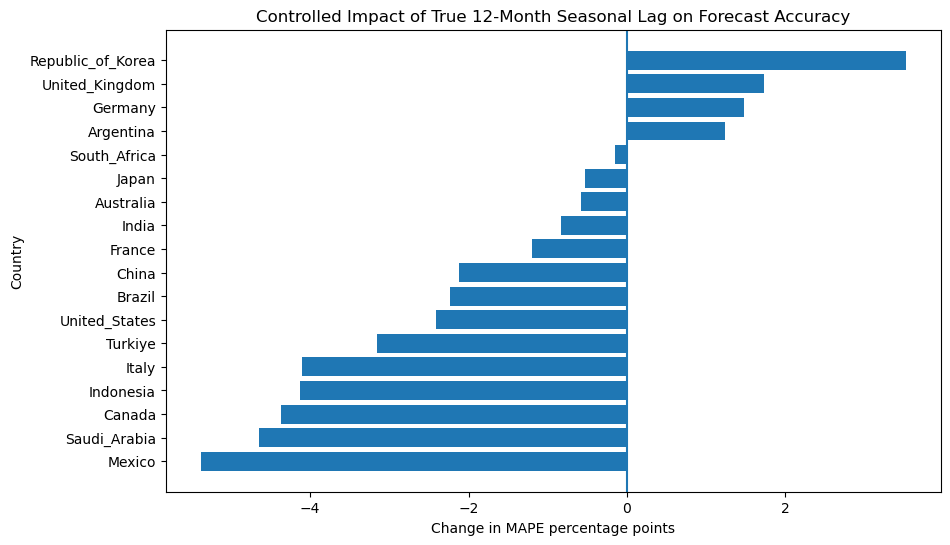

In [182]:
plot_data = controlled_country_comparison.sort_values(
    "MAPE_Change"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Country"],
    plot_data["MAPE_Change"]
)

plt.axvline(0)

plt.xlabel("Change in MAPE percentage points")
plt.ylabel("Country")
plt.title(
    "Controlled Impact of True 12-Month Seasonal Lag on Forecast Accuracy"
)

plt.show()

In [183]:
controlled_country_comparison.round(2).to_csv(
    "controlled_country_comparison.csv",
    index=False
)

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Country"],
    plot_data["MAPE_Change"]
)

plt.axvline(0)

plt.xlabel("Change in MAPE percentage points")
plt.ylabel("Country")
plt.title(
    "Controlled Impact of True 12-Month Seasonal Lag on Forecast Accuracy"
)

plt.tight_layout()

plt.savefig(
    "controlled_seasonal_lag_impact.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()